In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import tensorflow as tf

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-05-29 06:44:46.062355: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748501086.243788      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748501086.296233      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Num GPUs Available:  1


In [10]:
# Load annotations
annotations_path = "/kaggle/input/luna16/annotations.csv"
annotations_df = pd.read_csv(annotations_path)

# Display first few rows
print("Annotations DataFrame:")
print(annotations_df.head())

Annotations DataFrame:
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...  -24.013824  192.102405   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...    2.441547  172.464881   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  
3 -391.081276     8.143262  
4 -405.493732    18.545150  


In [ ]:
annotations_df.shape

In [11]:
# Load candidates_V2.csv
candidates_v2_path = "/kaggle/input/luna16/candidates.csv"
candidates_v2_df = pd.read_csv(candidates_v2_path)

# Display first few rows
print("Candidates_V2 DataFrame:")
print(candidates_v2_df.head())

# Explore class distribution
class_distribution = candidates_v2_df['class'].value_counts()
print("\nClass Distribution in Candidates_V2:")
print(class_distribution)

Candidates_V2 DataFrame:
                                           seriesuid  coordX  coordY  coordZ  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -56.08  -67.85 -311.92   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...   53.21 -244.41 -245.17   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.66 -121.80 -286.62   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -33.66  -72.75 -308.41   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -32.25  -85.36 -362.51   

   class  
0      0  
1      0  
2      0  
3      0  
4      0  

Class Distribution in Candidates_V2:
class
0    549714
1      1351
Name: count, dtype: int64


In [ ]:
# Path to the seg-lungs-LUNA16 folder
seg_lungs_path = "/kaggle/input/luna16/subset0/subset0"

# Extract seriesuid from filenames
seg_lungs_seriesuids = [
    os.path.splitext(filename)[0]  # Remove the .mhd extension
    for filename in os.listdir(seg_lungs_path)
    if filename.endswith(".mhd")
]

print(f"Number of unique seriesuids in seg-lungs-LUNA16: {len(seg_lungs_seriesuids)}")

In [12]:
# Extract unique seriesuids from candidates_v2_df
candidates_v2_seriesuids = candidates_v2_df['seriesuid'].unique()

# Extract unique seriesuids from annotations_df
annotations_seriesuids = annotations_df['seriesuid'].unique()

print(f"Number of unique seriesuids in candidates_V2: {len(candidates_v2_seriesuids)}")
print(f"Number of unique seriesuids in annotations: {len(annotations_seriesuids)}")

Number of unique seriesuids in candidates_V2: 888
Number of unique seriesuids in annotations: 601


In [13]:
import SimpleITK as sitk

# Load the CT scan
 
ct_image = sitk.ReadImage("/kaggle/input/luna16/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd")
ct_array = sitk.GetArrayFromImage(ct_image)

# Display metadata
print(f"CT Scan Shape: {ct_array.shape}")
print(f"Voxel Spacing: {ct_image.GetSpacing()}")
print(f"Origin: {ct_image.GetOrigin()}")

CT Scan Shape: (119, 512, 512)
Voxel Spacing: (0.7421879768371582, 0.7421879768371582, 2.5)
Origin: (-182.5, -190.0, -313.75)


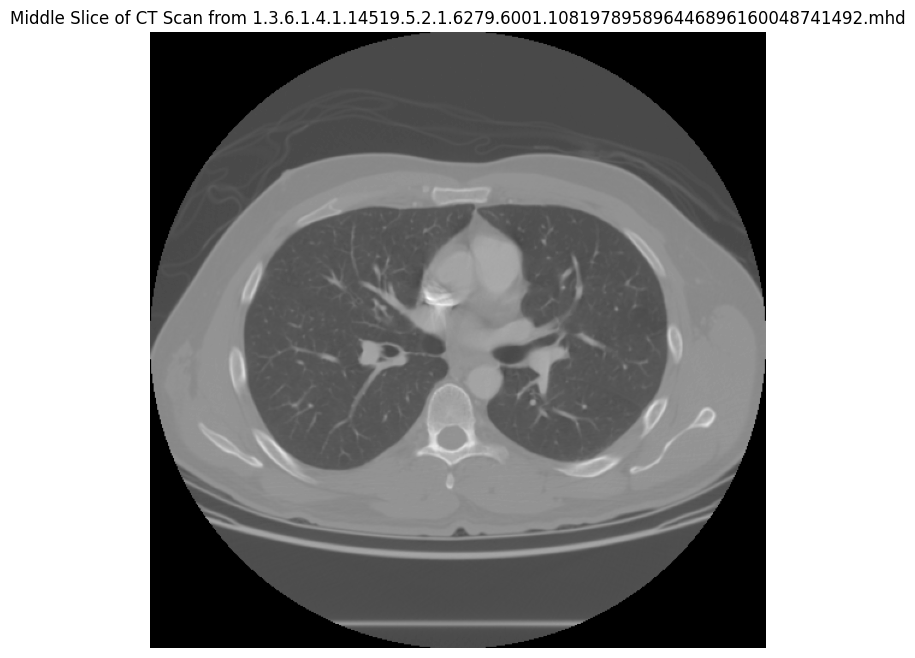

In [14]:
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt

# Path to a sample CT scan
sample_scan_path = "/kaggle/input/luna16/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd"

# Load the CT scan using SimpleITK
ct_image = sitk.ReadImage(sample_scan_path)
ct_array = sitk.GetArrayFromImage(ct_image)
# Display a middle slice
middle_slice_index = ct_array.shape[0] // 2
plt.figure(figsize=(8, 8))
plt.imshow(ct_array[middle_slice_index], cmap='gray')
plt.title(f"Middle Slice of CT Scan from {os.path.basename(sample_scan_path)}")
plt.axis('off')
plt.show()

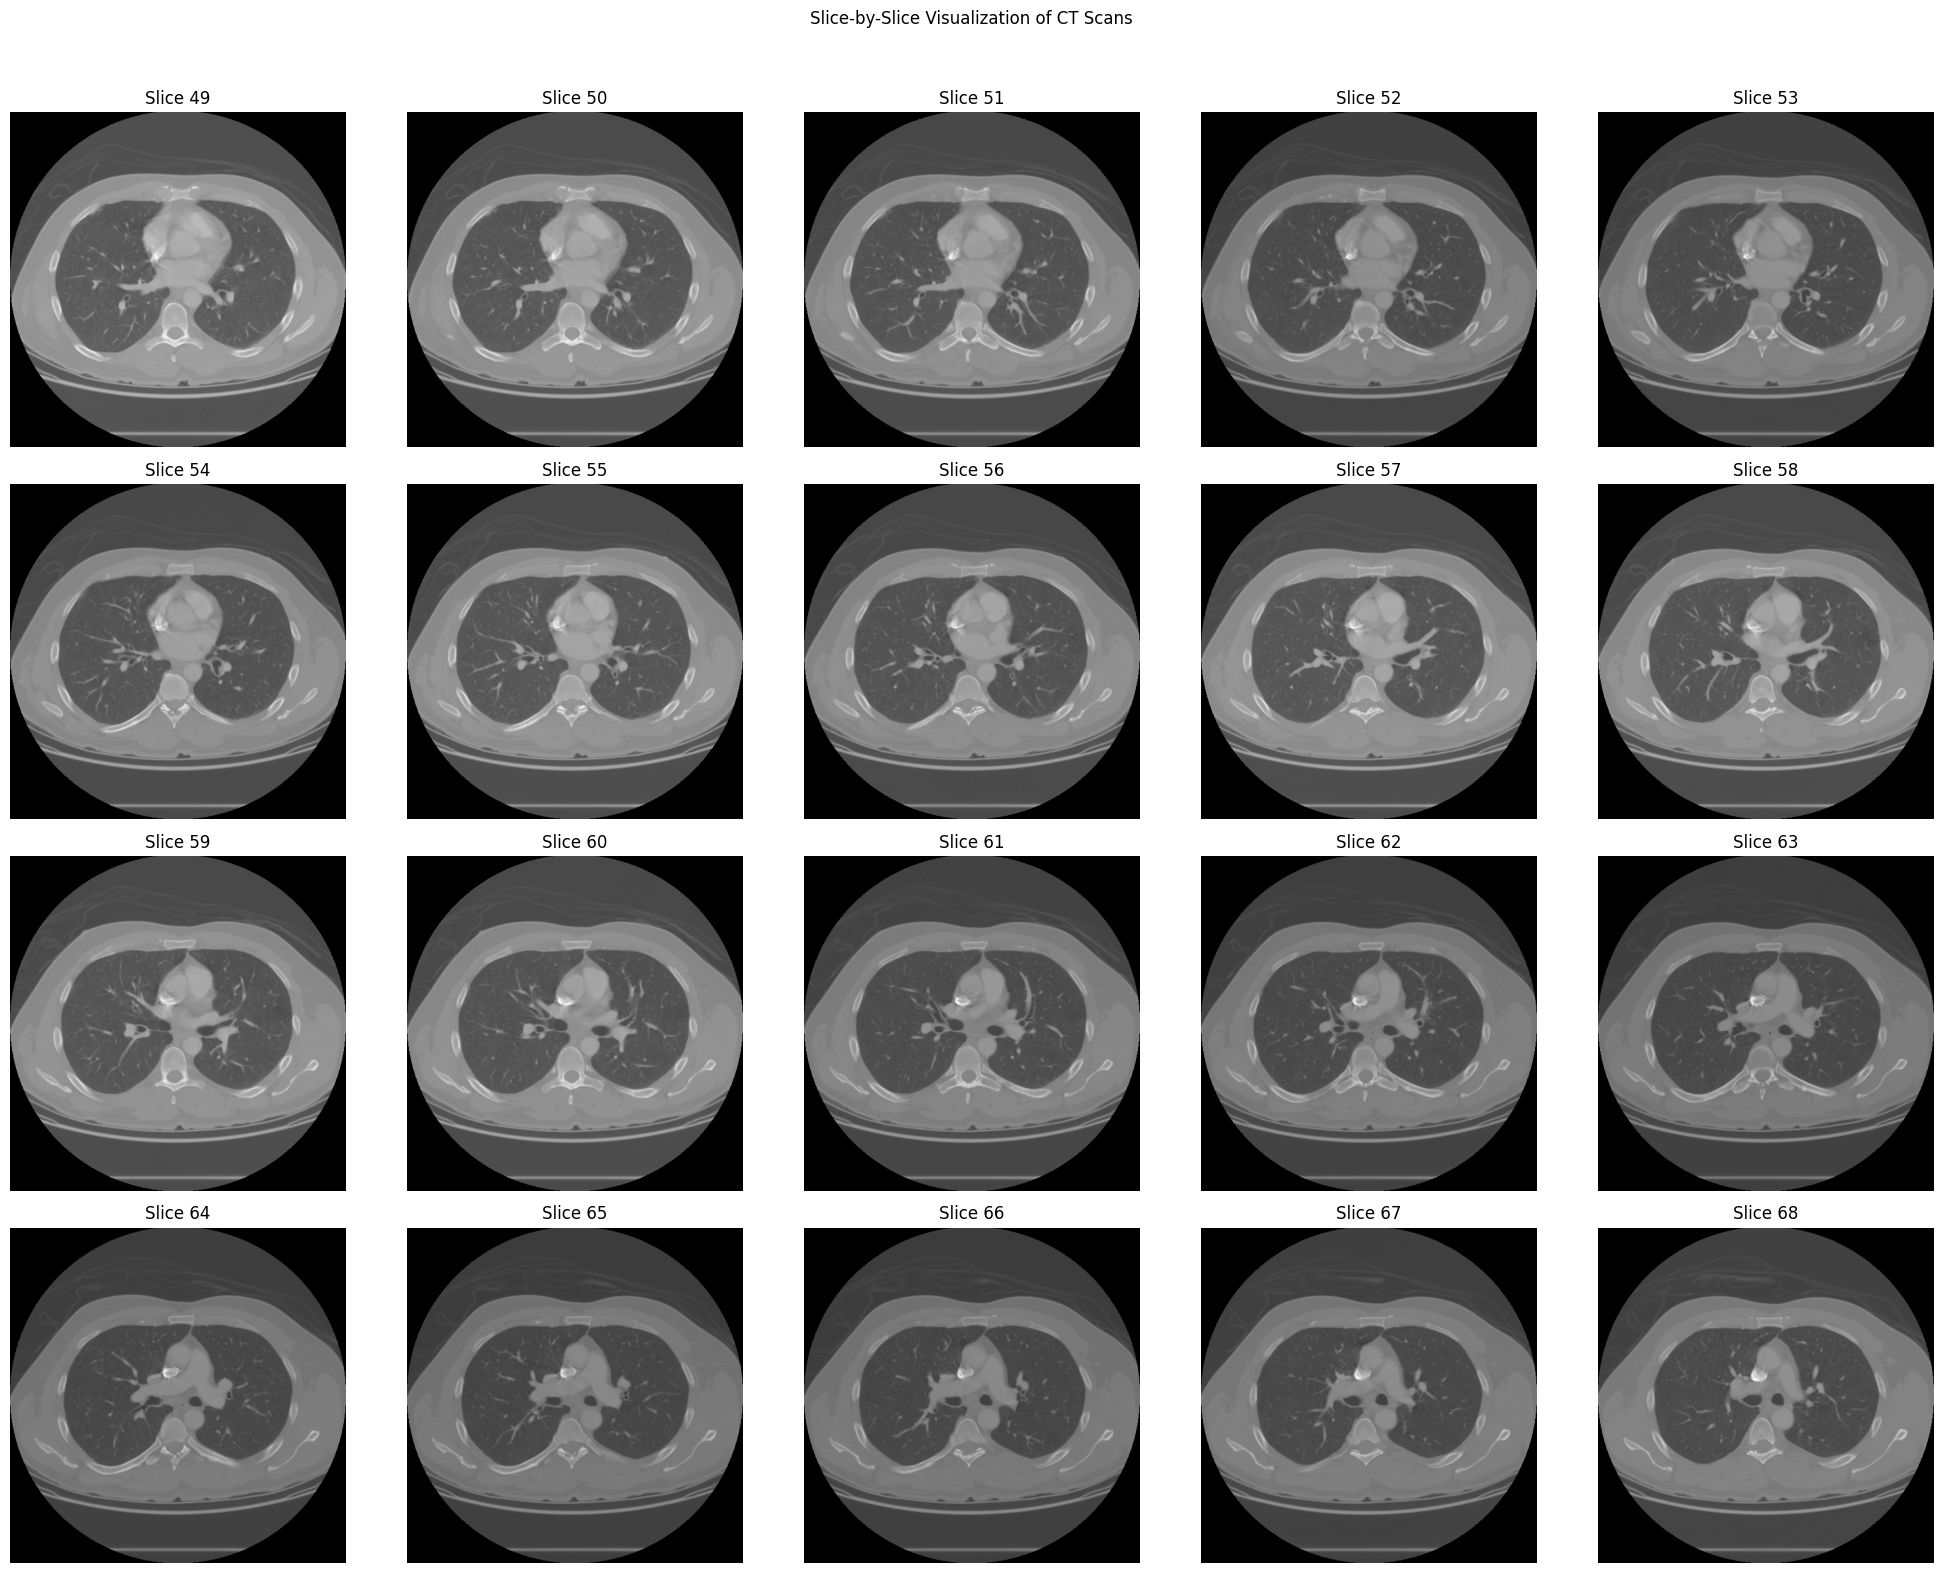

In [15]:
def plot_ct_slices(ct_scan):
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))  # 4 rows, 5 columns
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        slice_index = ct_scan.shape[0] // 2 + i - 10  # Center slices
        ax.imshow(ct_scan[slice_index], cmap='gray')
        ax.set_title(f"Slice {slice_index}")
        ax.axis('off')
    plt.suptitle("Slice-by-Slice Visualization of CT Scans")
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout for title
    plt.show()

# Example usage
plot_ct_slices(ct_array)

In [ ]:
import SimpleITK as sitk

# Path to the segmentation mask
segmentation_path = "/kaggle/input/luna16/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd"

# Load the segmentation mask
segmentation_mask = sitk.ReadImage(segmentation_path)
segmentation_array = sitk.GetArrayFromImage(segmentation_mask)

# Display metadata
print(f"Segmentation Mask Shape: {segmentation_array.shape}")

In [ ]:
def plot_segmentation_overlay(ct_scan, segmentation_mask):
    slice_index = ct_scan.shape[0] // 2  # Middle slice
    plt.figure(figsize=(10, 10))
    plt.imshow(ct_scan[slice_index], cmap='gray')  # Original CT scan
    plt.imshow(segmentation_mask[slice_index], cmap='jet', alpha=0.3)  # Segmented lungs
    plt.title("CT Scan with Lung Segmentation Overlay")
    plt.axis('off')
    plt.show()

# Example usage
plot_segmentation_overlay(ct_array, segmentation_array)

In [ ]:
import seaborn as sns

def plot_nodule_heatmap(annotations_df):
    coords = annotations_df[['coordX', 'coordY']].values
    heatmap, xedges, yedges = np.histogram2d(coords[:, 0], coords[:, 1], bins=50)
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap.T, cmap='viridis')
    plt.title("Nodule Location Heatmap")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.show()

# Example usage
plot_nodule_heatmap(annotations_df)

In [ ]:
def plot_candidate_distribution(candidates_df):
    coords = candidates_df[['coordX', 'coordY']].values
    heatmap, xedges, yedges = np.histogram2d(coords[:, 0], coords[:, 1], bins=50)
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap.T, cmap='viridis')
    plt.title("Candidate Location Heatmap")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.show()

# Example usage
plot_candidate_distribution(candidates_v2_df)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract nodule diameters from annotations_df
nodule_diameters = annotations_df['diameter_mm']

# Plot histogram of nodule diameters
plt.figure(figsize=(10, 6))
sns.histplot(nodule_diameters, bins=30, kde=True, color='blue')
plt.title("Distribution of Nodule Diameters")
plt.xlabel("Diameter (mm)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
# Count the number of nodules per seriesuid (patient)
nodule_counts_per_patient = annotations_df['seriesuid'].value_counts()

# Plot histogram of nodule counts
plt.figure(figsize=(10, 6))
sns.histplot(nodule_counts_per_patient, bins=20, kde=False, color='green')
plt.title("Distribution of Nodule Counts per Patient")
plt.xlabel("Number of Nodules")
plt.ylabel("Number of Patients")
plt.grid(True)
plt.show()

In [ ]:
# Extract X and Y coordinates of nodules
x_coords = annotations_df['coordX']
y_coords = annotations_df['coordY']

# Create 2D scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(x_coords, y_coords, alpha=0.5, color='blue', edgecolor='black')
plt.title("2D Scatter Plot of Nodule Coordinates (X vs Y)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Extract X, Y, and Z coordinates of nodules
x_coords = annotations_df['coordX']
y_coords = annotations_df['coordY']
z_coords = annotations_df['coordZ']

# Create 3D scatter plot
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_coords, y_coords, z_coords, alpha=0.5, color='purple', edgecolor='black')
ax.set_title("3D Scatter Plot of Nodule Coordinates")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_zlabel("Z Coordinate")
plt.show()

In [ ]:
import os
import SimpleITK as sitk

# Path to the seg-lungs-LUNA16 folder
seg_lungs_path = "/kaggle/input/luna16/subset0/subset0"

# Get a list of all .mhd files in the folder
mhd_files = [f for f in os.listdir(seg_lungs_path) if f.endswith(".mhd")]

print(f"Number of .mhd files: {len(mhd_files)}")

In [ ]:
import os
import cv2
import numpy as np
import SimpleITK as sitk
import pandas as pd
from scipy import ndimage
from tqdm import tqdm
import matplotlib.pyplot as plt

# === Paths ===
subset_path = "/kaggle/input/luna16/subset0/subset0"
annotations_csv = "/kaggle/input/luna16/annotations.csv"
output_images = "/kaggle/working/images"
output_labels = "/kaggle/working/labels"
os.makedirs(output_images, exist_ok=True)
os.makedirs(output_labels, exist_ok=True)

# === Load annotations ===
annotations_df = pd.read_csv(annotations_csv)

# === Utility Functions ===
def world_to_voxel(world_coord, origin, spacing):
    return ((world_coord - origin) / spacing).astype(int)

def normalize(volume):
    min_val, max_val = -1000, 400
    volume = np.clip(volume, min_val, max_val)
    return ((volume - min_val) / (max_val - min_val)).astype("float32")

def resize_volume(volume, target_shape=(128, 128, 64)):
    depth_factor = target_shape[2] / volume.shape[0]
    height_factor = target_shape[1] / volume.shape[1]
    width_factor = target_shape[0] / volume.shape[2]
    volume = np.transpose(volume, (1, 2, 0))  # Shape to (H, W, D)
    volume = ndimage.zoom(volume, (height_factor, width_factor, depth_factor), order=1)
    return volume  # Shape: (128, 128, 64)

def preprocess_slice(slice_img):
    # Normalize
    norm = normalize(slice_img)
    # Gaussian smoothing
    smoothed = cv2.GaussianBlur(norm, (3, 3), 0)
    # Contrast enhancement using CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # Convert to 8-bit for CLAHE
    smoothed_8bit = np.uint8(smoothed * 255)
    contrast = clahe.apply(smoothed_8bit)
    return contrast

def show_preprocessing_steps(image_array, i=100):
    original = image_array[i]
    norm = normalize(original)
    smoothed = cv2.GaussianBlur(norm, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast = clahe.apply(np.uint8(smoothed * 255))

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    axs[0].imshow(original, cmap="gray")
    axs[0].set_title("Original (HU)")
    axs[1].imshow(norm, cmap="gray")
    axs[1].set_title("Normalized")
    axs[2].imshow(smoothed, cmap="gray")
    axs[2].set_title("Gaussian Smoothing")
    axs[3].imshow(contrast, cmap="gray")
    axs[3].set_title("CLAHE Enhanced")
    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# === Main Processing ===
png_count = 0
label_count = 0

for file in tqdm(os.listdir(subset_path)):
    if not file.endswith(".mhd"):
        continue

    scan_path = os.path.join(subset_path, file)
    image = sitk.ReadImage(scan_path)
    image_array = sitk.GetArrayFromImage(image)  # (D, H, W)
    origin = np.array(image.GetOrigin())[::-1]
    spacing = np.array(image.GetSpacing())[::-1]

    # Normalize + Resize full volume (for model input)
    volume = normalize(image_array)
    resized_volume = resize_volume(volume)  # Shape: (128, 128, 64)

    series_uid = os.path.splitext(file)[0]
    nodules = annotations_df[annotations_df.seriesuid.str.strip().str.lower() == series_uid.strip().lower()]

    # Visualization for a single file only (first slice 100)
    show_preprocessing_steps(image_array, i=100)

    for i, slice_img in enumerate(image_array):  # Original resolution
        filename = f"{series_uid}_{i:03d}.png"
        image_path = os.path.join(output_images, filename)

        preprocessed = preprocess_slice(slice_img)
        resized = cv2.resize(preprocessed, (640, 640))
        cv2.imwrite(image_path, resized)
        png_count += 1

        label_path = os.path.join(output_labels, filename.replace('.png', '.txt'))
        with open(label_path, "w") as f:
            written = False
            for _, row in nodules.iterrows():
                center = world_to_voxel(np.array([row.coordZ, row.coordY, row.coordX]), origin, spacing)
                if center[0] == i:
                    x = center[2] / image_array.shape[2]
                    y = center[1] / image_array.shape[1]
                    w = h = (row.diameter_mm / spacing[1]) / image_array.shape[1]
                    if 0 <= x <= 1 and 0 <= y <= 1:
                        f.write(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
                        written = True
            if written:
                label_count += 1

print(f"\u2705 Done. Total PNGs saved: {png_count}, Label files with nodules: {label_count}")


In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

def show_image_with_labels(image_path, label_path=None):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    h, w = img.shape[:2]

    if label_path and os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x, y, box_w, box_h = map(float, line.strip().split())
                cx, cy = int(x * w), int(y * h)
                bw, bh = int(box_w * w), int(box_h * h)
                top_left = (cx - bw // 2, cy - bh // 2)
                bottom_right = (cx + bw // 2, cy + bh // 2)
                cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)
                cv2.putText(img, "nodule", (top_left[0], top_left[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Display a few random labeled images from /kaggle/working/images/
image_dir = "/kaggle/working/images"
label_dir = "/kaggle/working/labels"

# Filter only images that have non-empty label files
label_files = [f for f in os.listdir(label_dir) if os.path.getsize(os.path.join(label_dir, f)) > 0]
sample_labels = random.sample(label_files, 30)

for label_file in sample_labels:
    image_file = label_file.replace(".txt", ".png")
    show_image_with_labels(os.path.join(image_dir, image_file), os.path.join(label_dir, label_file))


In [ ]:
# ✅ Step 1: Split dataset into train/val/test
import os
import shutil
from sklearn.model_selection import train_test_split

# Set the base directory where all PNGs and labels are saved
images_dir = "/kaggle/working/images"
labels_dir = "/kaggle/working/labels"

# Create directories
base_output = "/kaggle/working/lung_dataset"
for split in ["train", "val", "test"]:
    os.makedirs(f"{base_output}/images/{split}", exist_ok=True)
    os.makedirs(f"{base_output}/labels/{split}", exist_ok=True)

# Get all image files
image_files = [f for f in os.listdir(images_dir) if f.endswith(".png")]

# Split
train_files, testval_files = train_test_split(image_files, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(testval_files, test_size=0.5, random_state=42)

# Function to copy image and label
def copy_files(files, split):
    for f in files:
        shutil.copy(os.path.join(images_dir, f), os.path.join(base_output, f"images/{split}", f))
        label_file = f.replace(".png", ".txt")
        label_src = os.path.join(labels_dir, label_file)
        if os.path.exists(label_src):
            shutil.copy(label_src, os.path.join(base_output, f"labels/{split}", label_file))

copy_files(train_files, "train")
copy_files(val_files, "val")
copy_files(test_files, "test")

In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs("/kaggle/working/yolov7/data", exist_ok=True)

# Now write the YAML file
lung_yaml = """
train: /kaggle/working/lung_dataset/images/train
val: /kaggle/working/lung_dataset/images/val

nc: 1
names: ['nodule']
"""
with open("/kaggle/working/yolov7/data/lung.yaml", "w") as f:
    f.write(lung_yaml)


In [ ]:
import os
os.chdir("/kaggle/working")


In [ ]:
!rm -rf yolov7


In [ ]:
# Step 1: Clone YOLOv7 repo and install requirements
!git clone https://github.com/WongKinYiu/yolov7 /kaggle/working/yolov7
%cd /kaggle/working/yolov7
!pip install -r requirements.txt


In [ ]:

!mkdir -p /kaggle/working/lung_dataset/images/train
!mkdir -p /kaggle/working/lung_dataset/images/val
!mkdir -p /kaggle/working/lung_dataset/labels/train
!mkdir -p /kaggle/working/lung_dataset/labels/val

In [ ]:
# Step 4: Create lung.yaml file
lung_yaml = """
train: /kaggle/working/lung_dataset/images/train
val: /kaggle/working/lung_dataset/images/val

nc: 1
names: ['nodule']
"""
with open("/kaggle/working/yolov7/data/lung.yaml", "w") as f:
    f.write(lung_yaml)


In [ ]:
%cd /kaggle/working/yolov7/


In [ ]:
import wandb

wandb.login(key="648184cc811b7d5495b84e3ff92288a099d9a0d8")

In [ ]:
%cd /kaggle/working/yolov7


In [ ]:
!wget https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt


In [ ]:
!python train.py --img 640 --batch 16 --epochs 10 --data data/lung.yaml --cfg cfg/training/yolov7.yaml --weights yolov7.pt --name lung_nodule_yolov7 --device 0


In [ ]:
!python test.py \
  --img 640 \
  --batch 16 \
  --data data/lung.yaml \
  --weights runs/train/lung_nodule_yolov7/weights/best.pt \
  --task test \
  --conf-thres 0.25 \
  --iou-thres 0.5 \
  --save-txt \
  --save-conf \
  --name lung_nodule_eval


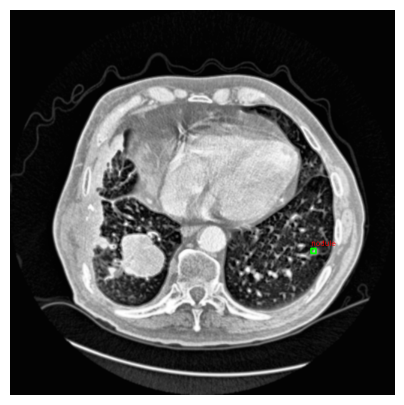

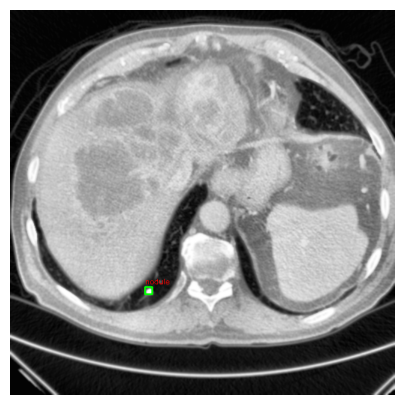

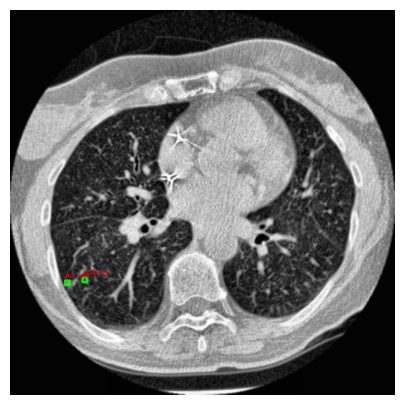

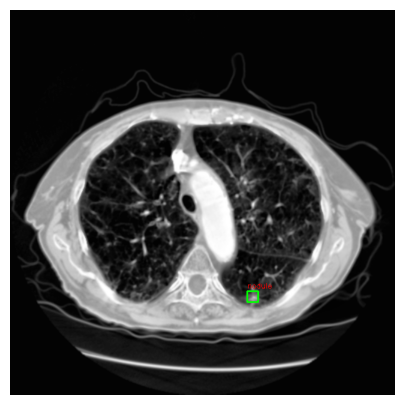

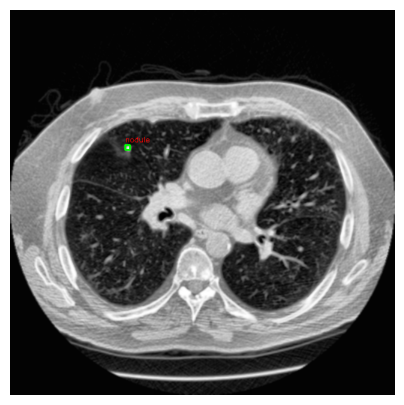

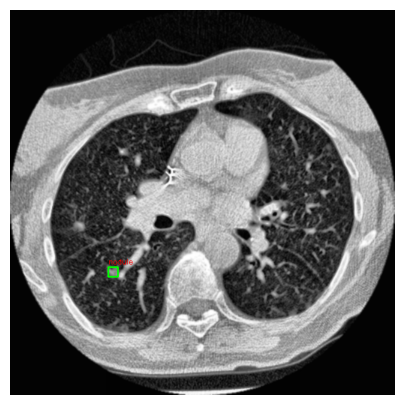

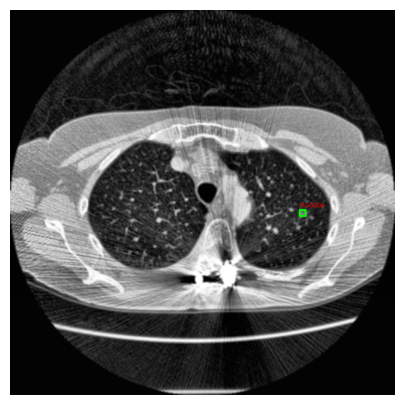

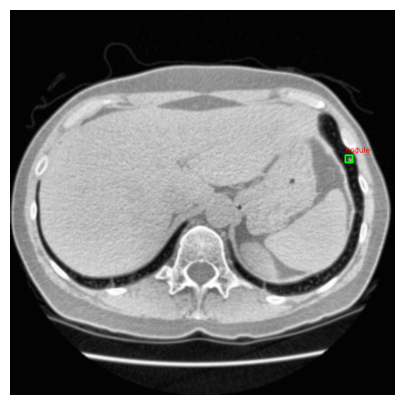

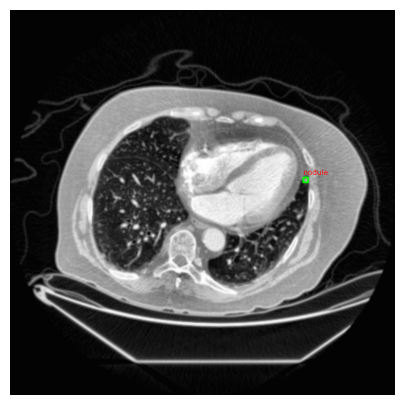

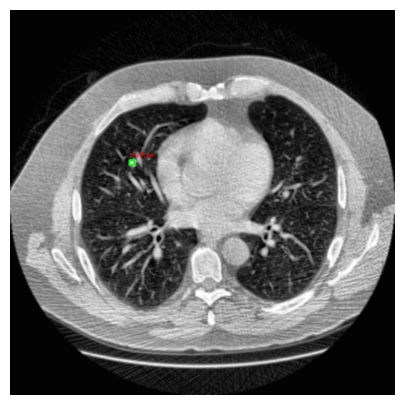

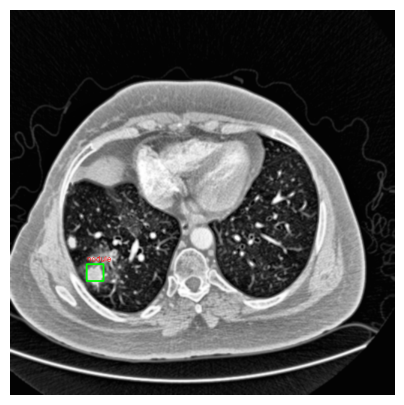

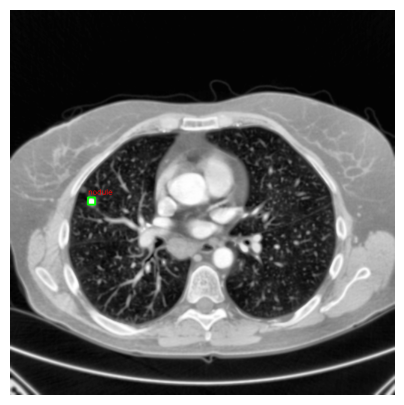

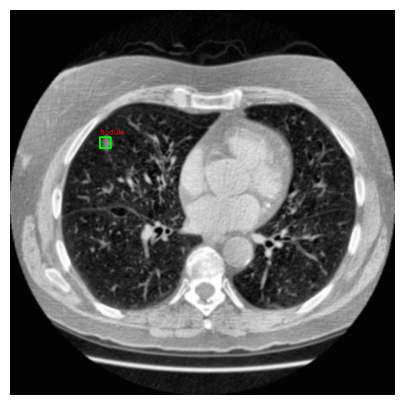

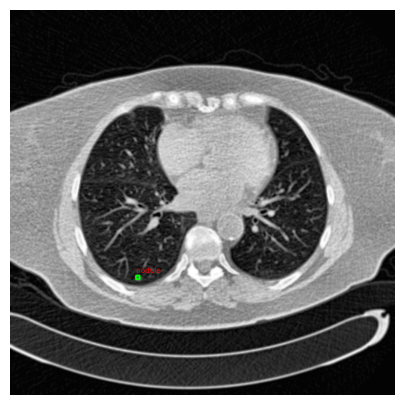

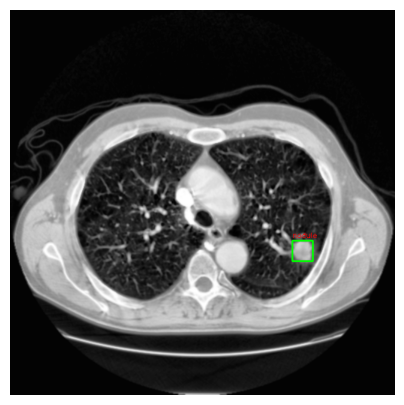

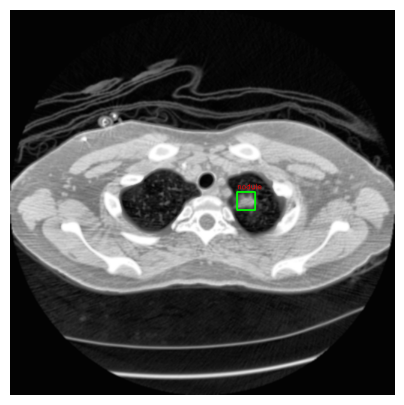

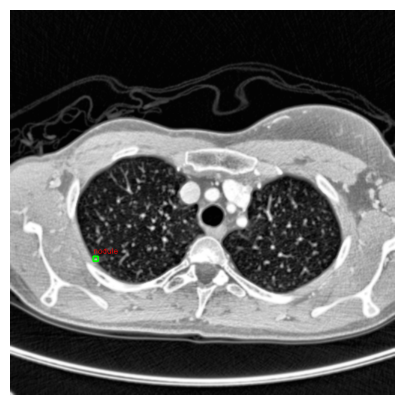

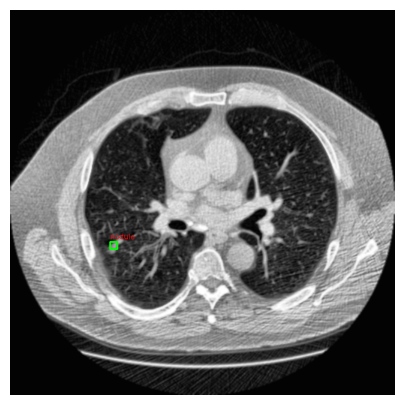

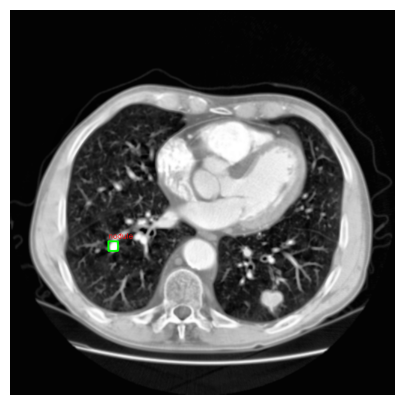

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

def show_image_with_labels(image_path, label_path=None):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    h, w = img.shape[:2]

    if label_path and os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x, y, box_w, box_h = map(float, line.strip().split())
                cx, cy = int(x * w), int(y * h)
                bw, bh = int(box_w * w), int(box_h * h)
                top_left = (cx - bw // 2, cy - bh // 2)
                bottom_right = (cx + bw // 2, cy + bh // 2)
                cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)
                cv2.putText(img, "nodule", (top_left[0], top_left[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

image_dir = "/kaggle/working/images"
label_dir = "/kaggle/working/labels"

label_files = [f for f in os.listdir(label_dir) if os.path.getsize(os.path.join(label_dir, f)) > 0]
sample_labels = random.sample(label_files, 30)

for label_file in sample_labels:
    image_file = label_file.replace(".txt", ".png")
    show_image_with_labels(os.path.join(image_dir, image_file), os.path.join(label_dir, label_file))
